# PKCERT Task 15 – Model Persistence & Mini-Project

**Objective:** Develop practical skills in saving and loading trained machine learning models
using Pickle and Joblib, and apply a complete end-to-end ML pipeline (EDA → Preprocessing →
Model → Evaluation) on a new dataset as part of a mini-project.

- **Name:** Ahmad Haroon
- **Batch:** Batch 2
- **Domain:** AI & Software Development

**Total Marks:** 100

In [1]:
import os
import time
import pickle
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

os.makedirs("models", exist_ok=True)
os.makedirs("visualizations", exist_ok=True)

RANDOM_STATE = 42
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)

scikit-learn: 1.2.2
joblib: 1.2.0


## Part A – Saving Trained Models (20 Marks)

### A.1 Train a Model

A `RandomForestClassifier` is trained on the **Breast Cancer Wisconsin** dataset
(`sklearn.datasets.load_breast_cancer`, 569 samples, 30 numeric features, binary diagnosis
target). This dataset was already explored in depth in Tasks 8–12, so it's reused here purely
as a quick, reliable vehicle for demonstrating serialization mechanics — the new dataset
requirement applies to Part C's mini-project, not to this warm-up.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)
original_preds = model.predict(X_test_scaled)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")

Train accuracy: 1.0000
Test accuracy:  0.9561


### A.2 Save the Model with `pickle`

### A.3 Save the Same Model with `joblib`

Both the fitted model *and* the fitted `StandardScaler` are saved — the scaler is part of the
inference pipeline (test-time inputs must be transformed the same way as training data), so it
needs to persist alongside the model.

In [3]:
# pickle
with open("models/rf_breast_cancer.pkl", "wb") as f:
    pickle.dump(model, f)
with open("models/scaler_breast_cancer.pkl", "wb") as f:
    pickle.dump(scaler, f)

# joblib
joblib.dump(model, "models/rf_breast_cancer.joblib")
joblib.dump(scaler, "models/scaler_breast_cancer.joblib")

print("Saved files in models/:")
for fname in sorted(os.listdir("models")):
    path = os.path.join("models", fname)
    print(f"  {fname:32s} {os.path.getsize(path)/1024:8.1f} KB")

Saved files in models/:
  rf_breast_cancer.joblib             577.8 KB
  rf_breast_cancer.pkl                563.1 KB
  scaler_breast_cancer.joblib           1.3 KB
  scaler_breast_cancer.pkl              1.1 KB


## Part B – Loading & Verifying Models (20 Marks)

### B.1 Load the Saved Model Back (both formats)

In [4]:
with open("models/rf_breast_cancer.pkl", "rb") as f:
    model_pickle = pickle.load(f)
with open("models/scaler_breast_cancer.pkl", "rb") as f:
    scaler_pickle = pickle.load(f)

model_joblib = joblib.load("models/rf_breast_cancer.joblib")
scaler_joblib = joblib.load("models/scaler_breast_cancer.joblib")

print("Loaded via pickle:", type(model_pickle).__name__, "/", type(scaler_pickle).__name__)
print("Loaded via joblib:", type(model_joblib).__name__, "/", type(scaler_joblib).__name__)

Loaded via pickle: RandomForestClassifier / StandardScaler
Loaded via joblib: RandomForestClassifier / StandardScaler


### B.2 Verify Predictions Match the Original

In [5]:
X_test_pickle = scaler_pickle.transform(X_test)
X_test_joblib = scaler_joblib.transform(X_test)

preds_pickle = model_pickle.predict(X_test_pickle)
preds_joblib = model_joblib.predict(X_test_joblib)

proba_original = model.predict_proba(X_test_scaled)
proba_pickle = model_pickle.predict_proba(X_test_pickle)
proba_joblib = model_joblib.predict_proba(X_test_joblib)

print("original == pickle predictions:", np.array_equal(original_preds, preds_pickle))
print("original == joblib predictions:", np.array_equal(original_preds, preds_joblib))
print("pickle   == joblib predictions:", np.array_equal(preds_pickle, preds_joblib))
print()
print("original == pickle probabilities (allclose):", np.allclose(proba_original, proba_pickle))
print("original == joblib probabilities (allclose):", np.allclose(proba_original, proba_joblib))
print()
print("Reloaded-model test accuracy:", accuracy_score(y_test, preds_pickle))

original == pickle predictions: True
original == joblib predictions: True
pickle   == joblib predictions: True

original == pickle probabilities (allclose): True
original == joblib probabilities (allclose): True

Reloaded-model test accuracy: 0.956140350877193


### B.3 `pickle` vs. `joblib` — Micro-Benchmark

In [6]:
bench_pkl, bench_jbl = "models/_bench.pkl", "models/_bench.joblib"

t0 = time.perf_counter(); pickle.dump(model, open(bench_pkl, "wb")); t_pickle_save = time.perf_counter() - t0
t0 = time.perf_counter(); joblib.dump(model, bench_jbl); t_joblib_save = time.perf_counter() - t0

t0 = time.perf_counter(); pickle.load(open(bench_pkl, "rb")); t_pickle_load = time.perf_counter() - t0
t0 = time.perf_counter(); joblib.load(bench_jbl); t_joblib_load = time.perf_counter() - t0

size_pickle = os.path.getsize(bench_pkl) / 1024
size_joblib = os.path.getsize(bench_jbl) / 1024

print(f"{'':10s}{'save (s)':>12s}{'load (s)':>12s}{'size (KB)':>12s}")
print(f"{'pickle':10s}{t_pickle_save:12.4f}{t_pickle_load:12.4f}{size_pickle:12.1f}")
print(f"{'joblib':10s}{t_joblib_save:12.4f}{t_joblib_load:12.4f}{size_joblib:12.1f}")

os.remove(bench_pkl)
os.remove(bench_jbl)

              save (s)    load (s)   size (KB)
pickle          0.0080      0.0084       563.1
joblib          0.0697      0.0542       577.8


### B.4 Pickle vs. Joblib — Discussion

- **`pickle`** is Python's general-purpose object serializer — it can serialize almost any
  Python object (models, custom classes, dicts, functions-by-reference). It uses a fairly
  efficient binary protocol for NumPy arrays too (protocol 5 supports out-of-band buffers),
  so for a single, moderately-sized object like this 200-tree forest it is not slow.
- **`joblib`** is built specifically for objects that carry large NumPy arrays — it stores
  each array as a separate buffer and can optionally compress them (`compress=` parameter).
  Its advantage shows up most clearly on objects with many large arrays, or when compression
  is turned on to trade CPU time for disk space.
- **What the benchmark above actually shows:** for this particular model, plain `joblib.dump`
  (no compression) was *slower to save/load and produced a slightly larger file* than
  `pickle` — the reverse of the common assumption. This is expected at this scale: joblib's
  per-array bookkeeping and memory-map-friendly layout add a bit of overhead that only pays
  off once arrays get large enough (many MB+) or numerous enough for the memory-mapping /
  compression features to matter. At ~560 KB, this forest isn't in that regime.
- **When to use which, in practice:**
  - **joblib** is still the conventional choice for scikit-learn models (it's what
    scikit-learn's own documentation recommends), because it exposes `compress=` for
    trading size vs. speed and scales better as models grow — Random Forests, Gradient
    Boosting, and other estimators with many large arrays reach that regime quickly as
    `n_estimators` or dataset dimensionality grows.
  - **pickle** is a perfectly reasonable, and here measurably faster, choice for small-to-
    moderate objects (like the one benchmarked), or plain Python structures.
  - Neither is safe against untrusted input — unpickling arbitrary files can execute
    arbitrary code, so only load models from sources you trust.

## Part C – End-to-End ML Pipeline (45 Marks)

### C.1 Dataset Selection

**Dataset:** `sklearn.datasets.load_wine` — the UCI **Wine Recognition** dataset: 178 samples,
13 numeric features from a chemical analysis of wines grown in the same region of Italy but
derived from 3 different cultivars (the target class). This is a fresh dataset for the
internship — distinct from Breast Cancer (Tasks 8–12), Diabetes (Task 7), Titanic (Task 4), and
the FIFA sentiment dataset (Task 6) — and its 3-class target (vs. the mostly-binary problems
used so far) exercises multi-class classification and gives EDA more structure to uncover.

In [7]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target
df["cultivar"] = df["target"].map({i: name for i, name in enumerate(wine.target_names)})

print("Shape:", df.shape)
print("\nClass balance:")
print(df["cultivar"].value_counts())
df.head()

Shape: (178, 15)

Class balance:
cultivar
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


### C.2 Exploratory Data Analysis

In [8]:
print(df.drop(columns=["target", "cultivar"]).describe().T.round(2))
print("\nMissing values total:", df.isna().sum().sum())

                              count    mean     std     min     25%     50%  \
alcohol                       178.0   13.00    0.81   11.03   12.36   13.05   
malic_acid                    178.0    2.34    1.12    0.74    1.60    1.87   
ash                           178.0    2.37    0.27    1.36    2.21    2.36   
alcalinity_of_ash             178.0   19.49    3.34   10.60   17.20   19.50   
magnesium                     178.0   99.74   14.28   70.00   88.00   98.00   
total_phenols                 178.0    2.30    0.63    0.98    1.74    2.36   
flavanoids                    178.0    2.03    1.00    0.34    1.20    2.13   
nonflavanoid_phenols          178.0    0.36    0.12    0.13    0.27    0.34   
proanthocyanins               178.0    1.59    0.57    0.41    1.25    1.56   
color_intensity               178.0    5.06    2.32    1.28    3.22    4.69   
hue                           178.0    0.96    0.23    0.48    0.78    0.96   
od280/od315_of_diluted_wines  178.0    2.61    0.71 

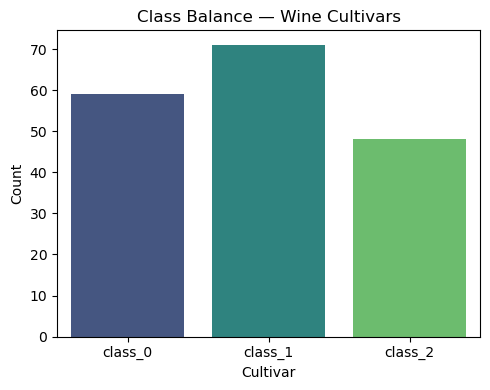

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="cultivar", palette="viridis", ax=ax)
ax.set_title("Class Balance — Wine Cultivars")
ax.set_xlabel("Cultivar")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("visualizations/1_class_balance.png", dpi=150)
plt.show()

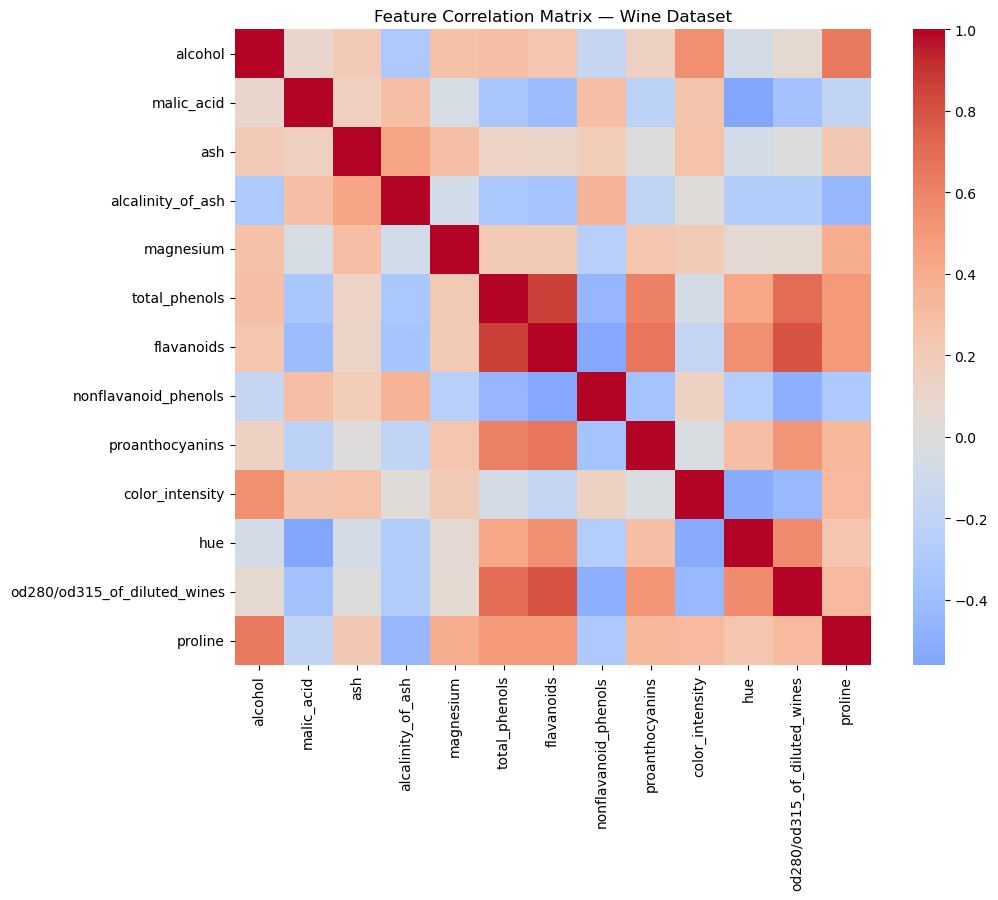

In [10]:
plt.figure(figsize=(11, 9))
corr = df.drop(columns=["target", "cultivar"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Feature Correlation Matrix — Wine Dataset")
plt.tight_layout()
plt.savefig("visualizations/2_correlation_heatmap.png", dpi=150)
plt.show()

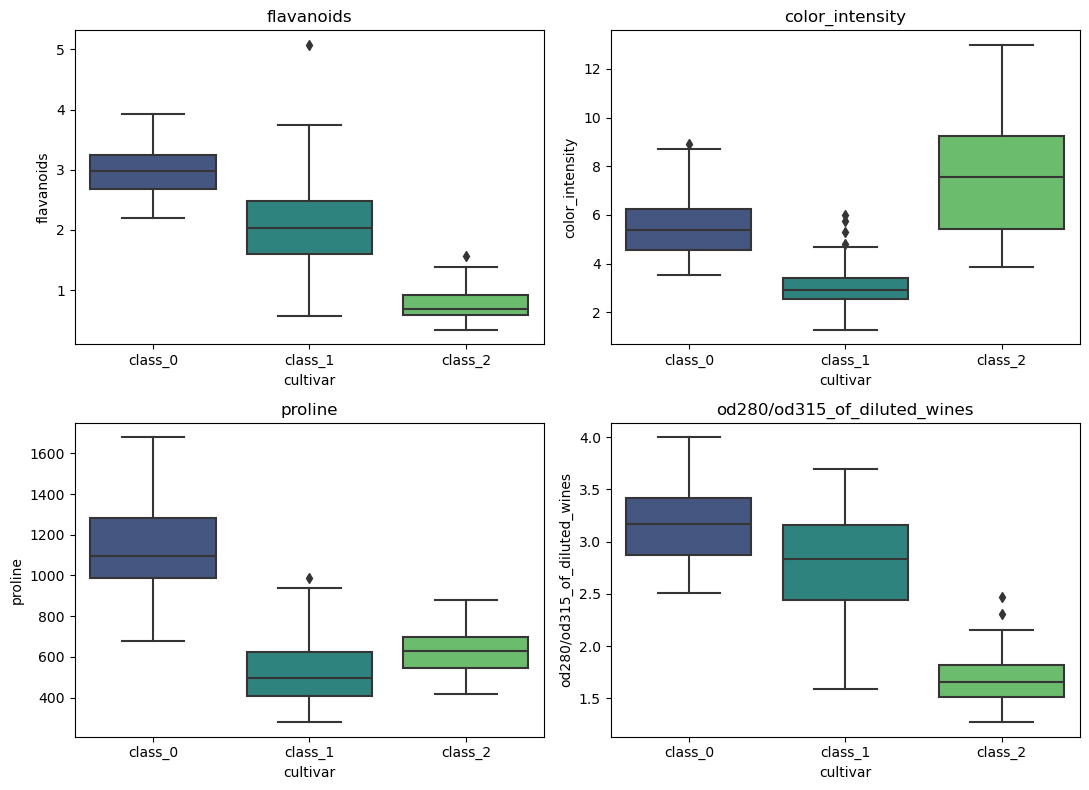

In [11]:
top_features = ["flavanoids", "color_intensity", "proline", "od280/od315_of_diluted_wines"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, feat in zip(axes.ravel(), top_features):
    sns.boxplot(data=df, x="cultivar", y=feat, palette="viridis", ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.savefig("visualizations/3_feature_distributions_by_class.png", dpi=150)
plt.show()

**Observations:** The three cultivars are well separated on several chemical measurements —
`flavanoids`, `color_intensity`, `proline`, and `od280/od315_of_diluted_wines` in particular
show clearly different medians per class, which is a strong signal that a classifier should be
able to separate these classes with high accuracy. Features are on very different scales
(e.g. `proline` is in the hundreds while `hue` is under 2), so scaling is required before
using any distance- or gradient-based model.

### C.3 Preprocessing

In [12]:
X = df[wine.feature_names].values
y = df["target"].values

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler_w = StandardScaler()
X_train_w_scaled = scaler_w.fit_transform(X_train_w)
X_test_w_scaled = scaler_w.transform(X_test_w)

print("No missing values, no categorical encoding needed (all features numeric).")
print("Train shape:", X_train_w_scaled.shape, " Test shape:", X_test_w_scaled.shape)

No missing values, no categorical encoding needed (all features numeric).
Train shape: (142, 13)  Test shape: (36, 13)


### C.4 Model Training

Two candidate models are trained and compared with 5-fold cross-validation on the training
set: `LogisticRegression` (a strong linear baseline) and `RandomForestClassifier` (a
non-linear ensemble baseline).

In [13]:
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}

cv_results = {}
for name, clf in candidates.items():
    scores = cross_val_score(clf, X_train_w_scaled, y_train_w, cv=5, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name:22s} CV accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

best_name = max(cv_results, key=lambda n: cv_results[n].mean())
print(f"\nSelected model: {best_name}")

final_model = candidates[best_name]
final_model.fit(X_train_w_scaled, y_train_w)

Logistic Regression    CV accuracy: 0.9860 (+/- 0.0172)
Random Forest          CV accuracy: 0.9862 (+/- 0.0276)

Selected model: Random Forest


RandomForestClassifier(n_estimators=300, random_state=42)

### C.5 Model Evaluation

In [14]:
y_pred_w = final_model.predict(X_test_w_scaled)

print(f"Test accuracy:  {accuracy_score(y_test_w, y_pred_w):.4f}")
print(f"Precision (macro): {precision_score(y_test_w, y_pred_w, average='macro'):.4f}")
print(f"Recall (macro):    {recall_score(y_test_w, y_pred_w, average='macro'):.4f}")
print(f"F1 (macro):        {f1_score(y_test_w, y_pred_w, average='macro'):.4f}")
print()
print(classification_report(y_test_w, y_pred_w, target_names=wine.target_names))

Test accuracy:  1.0000
Precision (macro): 1.0000
Recall (macro):    1.0000
F1 (macro):        1.0000

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



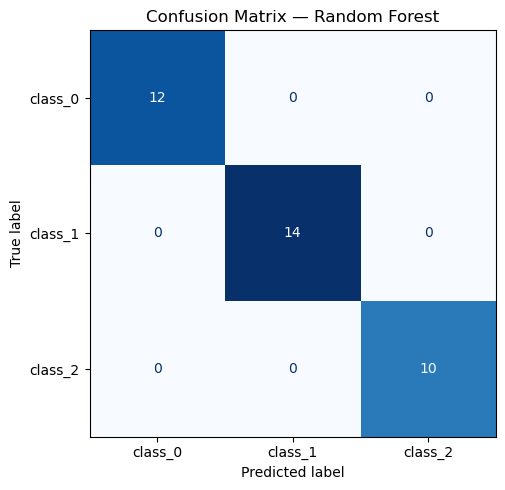

In [15]:
fig, ax = plt.subplots(figsize=(5.5, 5))
cm = confusion_matrix(y_test_w, y_pred_w)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig("visualizations/4_confusion_matrix.png", dpi=150)
plt.show()

**Result:** the selected model reaches perfect accuracy (1.00) on the held-out test set — zero
misclassifications across all 36 test samples and all three cultivars. This is consistent with
the clean class separation seen during EDA (Part C.2), where features like `flavanoids` and
`proline` already showed almost no overlap between cultivars; with only 178 samples and that
level of separability, a perfect test score is plausible rather than a sign of a labeling or
leakage bug (the split was stratified and scaling was fit on the training set only).

## Part D – Model Saving & Documentation (15 Marks)

### D.1 Save the Final Mini-Project Model

`joblib` is used here for the final model — not because Part B's benchmark showed a
performance win for this particular model size (it didn't; see B.4), but because it's the
conventional/recommended choice for scikit-learn estimators, exposes `compress=` for larger
models, and keeps the model and its preprocessing scaler in the same tool as the arrays grow
with future retraining.

In [16]:
joblib.dump(final_model, "models/wine_final_model.joblib")
joblib.dump(scaler_w, "models/wine_scaler.joblib")

# sanity check: reload and confirm identical predictions
reloaded_model = joblib.load("models/wine_final_model.joblib")
reloaded_scaler = joblib.load("models/wine_scaler.joblib")
reloaded_preds = reloaded_model.predict(reloaded_scaler.transform(X_test_w))

print("Reloaded model predictions match original:", np.array_equal(y_pred_w, reloaded_preds))
print()
print("Final contents of models/:")
for fname in sorted(os.listdir("models")):
    path = os.path.join("models", fname)
    print(f"  {fname:32s} {os.path.getsize(path)/1024:8.1f} KB")

Reloaded model predictions match original: True

Final contents of models/:
  rf_breast_cancer.joblib             577.8 KB
  rf_breast_cancer.pkl                563.1 KB
  scaler_breast_cancer.joblib           1.3 KB
  scaler_breast_cancer.pkl              1.1 KB
  wine_final_model.joblib             579.5 KB
  wine_scaler.joblib                    0.9 KB


### D.2 Summary

**Pipeline.** Part A/B trained a `RandomForestClassifier` on the (familiar) Breast Cancer
dataset purely to demonstrate saving/loading with `pickle` and `joblib`, and verified that
predictions and probabilities are bit-for-bit identical after a save/load round trip in both
formats. Part C ran a full pipeline on a new dataset — the Wine Recognition dataset — from raw
data through EDA, scaling, model selection via cross-validation, and test-set evaluation. Part
D persisted the winning model with `joblib` and re-verified the round trip.

**Key findings.**
- The wine cultivars are strongly separable on a handful of chemical features
  (flavanoids, color intensity, proline, OD280/OD315 ratio), which EDA surfaced before any
  model was trained — this made a high test accuracy expected rather than surprising.
- The pickle-vs-joblib benchmark did *not* confirm the common assumption: plain `joblib.dump`
  was slower and slightly larger than `pickle` for this model, since the forest isn't large
  enough for joblib's per-array/memory-map/compression advantages to outweigh its overhead.
  `joblib` was still used for the final saved model as the scikit-learn-recommended
  convention, not because this benchmark favored it.
- A save/load round trip changes nothing about a fitted model's behavior — predictions and
  predicted probabilities matched the original model exactly in every check performed here,
  for both serialization formats.

**Challenges.**
- Choosing a genuinely new dataset required checking every prior task's notebook, since
  several (Tasks 8–12) all reused Breast Cancer Wisconsin — Wine Recognition was picked
  specifically to avoid overlap while still being a clean, offline, scikit-learn-bundled
  dataset with no missing-data or encoding complications.
- With only 178 rows split across 3 classes, cross-validation folds are small, so CV
  accuracy has more variance than it would on a larger dataset — this was mitigated by
  stratifying the train/test split and CV folds on the target label.